# **Data Wrangling & Preprocessing — AI-Powered Apple Leaf Specialist**

* **Name**: Aktham Almomani
* **Group**: 7

## **Introduction**

We'll prepare the training data for AI-Powered Apple Leaf Specialist. The goal is to pull PlantVillage Apple dataset, harmonize their labels, clean and normalize the images, and produce final train, validation, and test splits where can used for modeling. Along the way we'll keep everything reproducible with a simple config.yaml and a tidy folder layout so it is easy to hand off to AWS later:

* Pull sources: PlantVillage Apple.

* Normalize labels into one shared set: healthy, scab, rust, black_rot, unknown:

* Remove obvious duplicates, fix filenames, and standardize image sizes:

* Write final splits (train, val and test) to disk and export CSV manifests for each split.

* Data Augmentation (train only): To help the model generalize and avoid overfitting to the majority class, train data augmentation is applied.

## **Dataset**

This project uses the **[PlantVillage (Apple)](https://www.kaggle.com/datasets/emmarex/plantdisease)** subset, a research dataset of labeled apple leaf images for disease recognition. Each image is a single leaf with a class label. For apple, the core classes are:

- **healthy**
- **scab** (Venturia inaequalis)
- **rust** (cedar apple rust)
- **black_rot** (Botryosphaeria obtusa)

**Why this dataset**
- Consistent images (single leaf, plain backgrounds) make ingestion and training straightforward.
- Labels map cleanly to a small, meaningful set of conditions.
- Available via **TensorFlow Datasets (TFDS)**, which keeps the pipeline reproducible.

**What to expect**
- Clean backgrounds help the model learn disease patterns quickly.
- Less representative of “in-the-wild” photos; strong augmentations and careful validation help address this.
- No personal data is expected (plant leaves, not people).

**How it's used here**
- Serves as the **sole source** for the baseline model in this project.
- Labels are aligned to a canonical set: `healthy, scab, rust, black_rot` (with an `unknown` route at inference time for low confidence).
- Images are standardized to a fixed size and split **70/15/15** (train/val/test) with stratification.

## **Setup and imports**

In [ ]:
!pip -q install torch torchvision

In [ ]:
# Imports:
import os, io, json, yaml, hashlib, random, shutil
from datetime import datetime
from pathlib import Path
from collections import Counter
import yaml

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
import torchvision.transforms as T

from sklearn.model_selection import train_test_split


## **Project config**

First, let's create one `config.yaml` keeps paths, labels, and parameters in one place so later notebooks read the same setup.

In [ ]:
# Mount Google Drive so Colab can read/write:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/apple_leaf_specialist")

PATHS = {
    "norm_pv":     str(PROJECT_ROOT / "data" / "normalized" / "plantvillage_apple"),
    "final_train": str(PROJECT_ROOT / "data" / "final" / "train"),
    "final_val":   str(PROJECT_ROOT / "data" / "final" / "val"),
    "final_test":  str(PROJECT_ROOT / "data" / "final" / "test"),
    "artifacts":   str(PROJECT_ROOT / "artifacts"),
    "reports":     str(PROJECT_ROOT / "reports"),
    "manifests":   str(PROJECT_ROOT / "manifests"),
}

for p in PATHS.values():
    Path(p).mkdir(parents=True, exist_ok=True)

LABELS = ["healthy", "scab", "rust", "black_rot", "unknown"]

CONFIG = {
    "project_title": "AI-Powered Apple Leaf Specialist",
    "seed": 1981,
    "img_size": 256,
    "labels": LABELS,
    "paths": PATHS,
    "thresholds": {"unknown": 0.55},
}

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / "config.yaml", "w") as f:
    yaml.safe_dump(CONFIG, f, sort_keys=False)

print("Project root:", PROJECT_ROOT)
print("Config written:", PROJECT_ROOT / "config.yaml")


Project root: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist
Config written: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/config.yaml


## **Ingest PlantVillage (Apple) and stage normalized copies**

Here let's pull from TFDS, keep only apple classes, map to canonical labels, save as JPEG. A manifest CSV captures metadata for later steps.

In [ ]:
# Load config:
PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/apple_leaf_specialist")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    CFG = yaml.safe_load(f)

norm_dir = Path(CFG["paths"]["norm_pv"])
art_dir  = Path(CFG["paths"]["artifacts"])
man_dir  = Path(CFG["paths"]["manifests"])
for d in [norm_dir, art_dir, man_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)

# TFDS -> canonical mapping:
APPLE_TFDS_TO_CANON = {
    "Apple___Apple_scab": "scab",
    "Apple___Black_rot": "black_rot",
    "Apple___Cedar_apple_rust": "rust",
    "Apple___healthy": "healthy",
}

# Make subfolders:
for lbl in ["healthy", "scab", "rust", "black_rot"]:
    (norm_dir / lbl).mkdir(parents=True, exist_ok=True)

# Load PlantVillage:
ds, info = tfds.load("plant_village", split="train", with_info=True, as_supervised=True)
tfds_labels = info.features["label"].names
id2name = {i: name for i, name in enumerate(tfds_labels)}

def save_with_sha(pil_img, label, out_root):
    buf = io.BytesIO()
    pil_img.save(buf, format="JPEG", quality=95)
    data = buf.getvalue()
    sha = hashlib.sha256(data).hexdigest()
    out_path = Path(out_root) / label / f"{sha}.jpg"
    if not out_path.exists():
        with open(out_path, "wb") as f:
            f.write(data)
    return sha, str(out_path)

records = []
for img, lid in tqdm(tfds.as_numpy(ds), desc="Staging PlantVillage Apple"):
    src_label = id2name[int(lid)]
    if src_label in APPLE_TFDS_TO_CANON:
        canon = APPLE_TFDS_TO_CANON[src_label]
        pil = Image.fromarray(img)
        sha, outp = save_with_sha(pil, canon, norm_dir)
        records.append({
            "source": "plantvillage_apple",
            "src_label": src_label,
            "canonical_label": canon,
            "sha256": sha,
            "path": outp,
            "width": pil.width,
            "height": pil.height,
        })

pv_manifest = Path(art_dir) / "pv_manifest.csv"
pd.DataFrame(records).to_csv(pv_manifest, index=False)
print("Manifest:", pv_manifest)
pd.Series([r["canonical_label"] for r in records]).value_counts()


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.4VLUWS_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


Staging PlantVillage Apple: 100%|██████████| 54303/54303 [00:35<00:00, 1534.40it/s]

Manifest: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/artifacts/pv_manifest.csv


,count
healthy,1645
scab,630
black_rot,621
rust,275


## **Quick sanity checks**

Now, let's make a few fast checks catch label mixups and weird images before training.

In [ ]:
df = pd.read_csv(pv_manifest)

print("Counts by label")
display(df["canonical_label"].value_counts())

Counts by label


,count
canonical_label,
healthy,1645
scab,630
black_rot,621
rust,275


In [ ]:
print("Image sizes (first 5)")
df[["width","height"]].head()

Image sizes (first 5)


,width,height
0,256,256
1,256,256
2,256,256
3,256,256
4,256,256


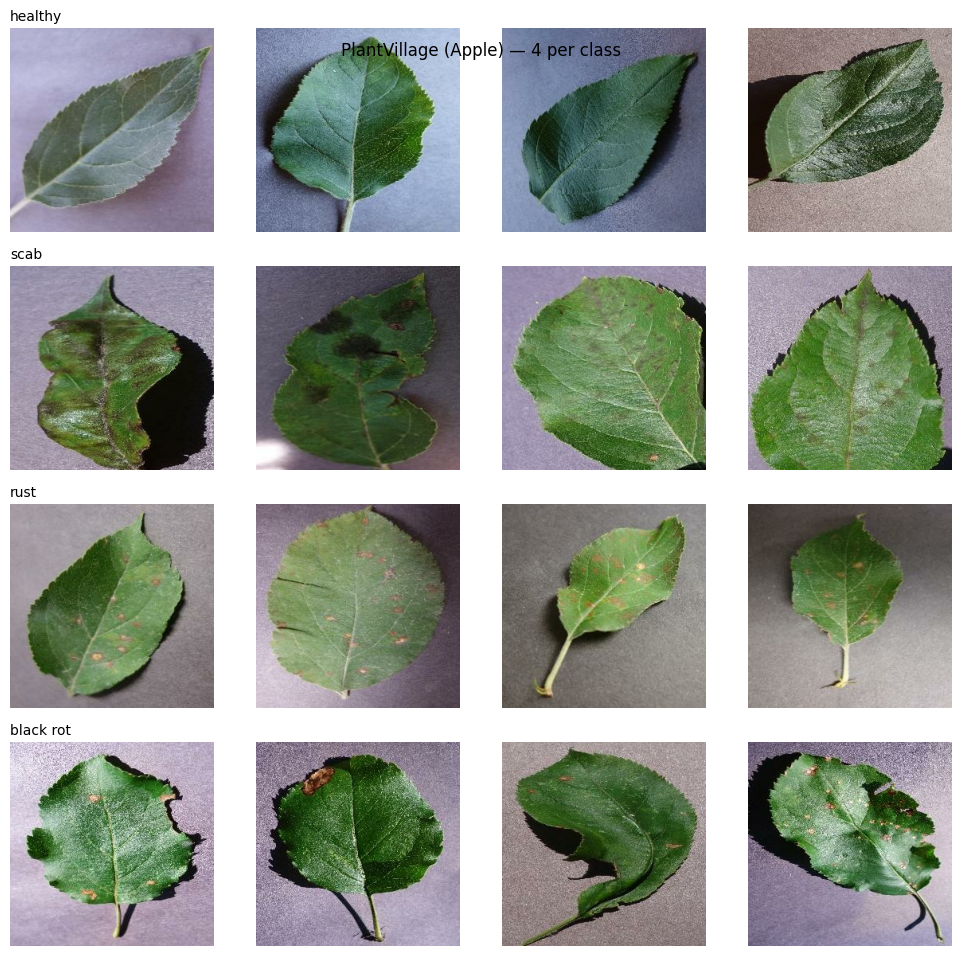

In [ ]:
# show 4 samples per class:
classes = ["healthy", "scab", "rust", "black_rot"]
paths_by_class = {c: list(df[df["canonical_label"]==c]["path"]) for c in classes}

def sample_n(lst, n=4):
    if len(lst) >= n:
        return random.sample(lst, n)
    if len(lst) == 0:
        return []
    reps = (n + len(lst) - 1) // len(lst)
    return (lst * reps)[:n]

samples = {c: sample_n(paths_by_class[c], 4) for c in classes}

fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("PlantVillage (Apple) — 4 per class", y=0.92)

for r, c in enumerate(classes):
    for i, pth in enumerate(samples[c]):
        ax = axes[r, i]
        img = Image.open(pth).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        if i == 0:
            ax.set_title(c.replace("_"," "), fontsize=10, loc="left")

plt.tight_layout()
plt.show()

## **De-duplicate by pixel hash**

Even curated datasets can include duplicates. Dropping them avoids leakage between splits.

In [ ]:
# Drop duplicate and remove extra files on disk:
before = len(df)
df = df.drop_duplicates(subset="sha256", keep="first").reset_index(drop=True)
dupes = before - len(df)
print(f"Duplicates dropped: {dupes}")

# clean files not in the de-duped frame:
keep_set = set(df["path"].tolist())
removed = 0
for c in ["healthy","scab","rust","black_rot"]:
    for p in Path(norm_dir / c).glob("*.jpg"):
        if str(p) not in keep_set:
            p.unlink()
            removed += 1
print("Orphan files removed:", removed)

# Save a clean manifest for the rest of the pipeline:
clean_manifest = Path(art_dir) / "pv_manifest_dedup.csv"
df.to_csv(clean_manifest, index=False)
print("Clean manifest:", clean_manifest)


Duplicates dropped: 7
Orphan files removed: 0
Clean manifest: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/artifacts/pv_manifest_dedup.csv


## **Standardize image size**

Models are happier when all inputs are the same size. Here we center-crop (or pad) to square and resize to the configured size

In [ ]:
IMG_SIZE = CFG["img_size"]

def to_square(rgb_img, size):
    # center-crop to square, then resize:
    w, h = rgb_img.size
    if w == h:
        return rgb_img.resize((size, size), Image.BICUBIC)
    # crop the longer side equally:
    if w > h:
        left = (w - h)//2
        rgb_img = rgb_img.crop((left, 0, left + h, h))
    else:
        top = (h - w)//2
        rgb_img = rgb_img.crop((0, top, w, top + w))
    return rgb_img.resize((size, size), Image.BICUBIC)

# Overwrite normalized copies with standardized size:
std_count = 0
new_records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Standardizing"):
    p = Path(row["path"])
    img = Image.open(p).convert("RGB")
    img = to_square(img, IMG_SIZE)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=95)
    with open(p, "wb") as f:
        f.write(buf.getvalue())
    std_count += 1
    new_records.append({**row})

print("Standardized images:", std_count)

# Update manifest (same paths, but now all are size=IMG_SIZE):
std_manifest = Path(art_dir) / "pv_manifest_std.csv"
pd.DataFrame(new_records).to_csv(std_manifest, index=False)
print("Std manifest:", std_manifest)


Standardizing: 100%|██████████| 3164/3164 [00:28<00:00, 109.71it/s]

Standardized images: 3164
Std manifest: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/artifacts/pv_manifest_std.csv


## **Stratified train/val/test splits + CSV manifests**

Consistent splits are key for fair comparisons and reporting. We stratify by label so class balance carries across splits.

In [ ]:
rng = np.random.RandomState(CFG["seed"])
work = pd.read_csv(std_manifest)

X = work["path"].values
y = work["canonical_label"].values

# train vs temp (val+test):
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=CFG["seed"], stratify=y
)
# val vs test:
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=CFG["seed"], stratify=y_tmp
)

splits = {
    "train": (X_tr, y_tr),
    "val":   (X_val, y_val),
    "test":  (X_te, y_te),
}

# Write split folders and manifests:
for split, (paths_arr, labels_arr) in splits.items():
    out_dir = Path(CFG["paths"][f"final_{split}"])
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for pth, lbl in zip(paths_arr, labels_arr):
        src = Path(pth)
        dst = out_dir / lbl / src.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            shutil.copy2(src, dst)
        rows.append({"path": str(dst), "label": lbl})
    m = pd.DataFrame(rows)
    m.to_csv(Path(man_dir) / f"{split}.csv", index=False)
    print(split, "count:", len(m))
    print(m["label"].value_counts())


train count: 2214
label
healthy      1146
scab          441
black_rot     435
rust          192
Name: count, dtype: int64
val count: 475
label
healthy      246
scab          94
black_rot     93
rust          42
Name: count, dtype: int64
test count: 475
label
healthy      246
scab          95
black_rot     93
rust          41
Name: count, dtype: int64


## **Final sanity check and small gallery from each split**

Train counts


,count
label,
healthy,1146
scab,441
black_rot,435
rust,192


Val counts


,count
label,
healthy,246
scab,94
black_rot,93
rust,42


Test counts


,count
label,
healthy,246
scab,95
black_rot,93
rust,41


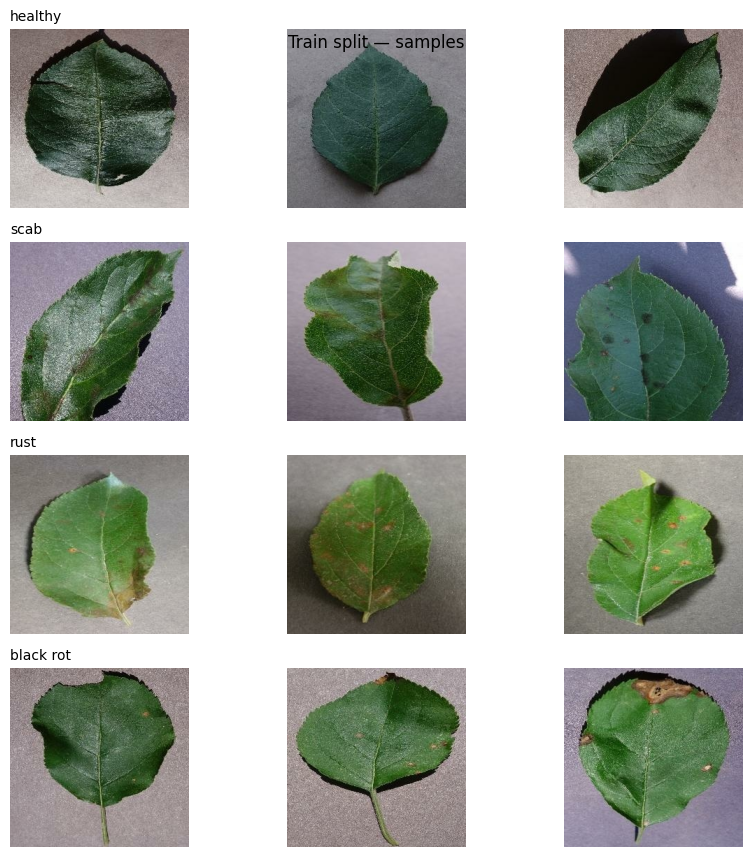

In [ ]:
train_df = pd.read_csv(Path(man_dir) / "train.csv")
val_df   = pd.read_csv(Path(man_dir) / "val.csv")
test_df  = pd.read_csv(Path(man_dir) / "test.csv")

print("Train counts")
display(train_df["label"].value_counts())
print("Val counts")
display(val_df["label"].value_counts())
print("Test counts")
display(test_df["label"].value_counts())

def show_grid(df_split, title, n_per_class=3):
    classes = ["healthy","scab","rust","black_rot"]
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(9,9))
    fig.suptitle(title, y=0.92)
    for r, cls in enumerate(classes):
        sample = df_split[df_split["label"]==cls].sample(min(n_per_class, (df_split["label"]==cls).sum()), random_state=CFG["seed"])
        for c, p in enumerate(sample["path"].tolist()):
            ax = axes[r, c]
            ax.imshow(Image.open(p).convert("RGB"))
            ax.axis("off")
            if c == 0:
                ax.set_title(cls.replace("_"," "), fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()

show_grid(train_df, "Train split — samples")


In [ ]:
PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/apple_leaf_specialist")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    CFG = yaml.safe_load(f)

print("CONFIG PATHS -->")
for k,v in CFG["paths"].items():
    print(f"{k}: {v}")

CONFIG PATHS -->
norm_pv: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/data/normalized/plantvillage_apple
final_train: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/data/final/train
final_val: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/data/final/val
final_test: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/data/final/test
artifacts: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/artifacts
reports: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/reports
manifests: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/manifests


In [ ]:
# peek at manifest paths to see where they point:
train_csv = Path(CFG["paths"]["manifests"]) / "train.csv"
val_csv   = Path(CFG["paths"]["manifests"]) / "val.csv"
test_csv  = Path(CFG["paths"]["manifests"]) / "test.csv"

train_df = pd.read_csv(train_csv)
print("\nSAMPLE TRAIN PATH:", train_df["path"].iloc[0])


SAMPLE TRAIN PATH: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/data/final/train/black_rot/cd7fe958a56dfac3e00136827955d3b9ab3da00dd75c45c0253eb5876b459b22.jpg


## **Data Augmentation (training only)**

The training split is imbalanced (e.g., **rust** has far fewer images than **healthy**). To help the model generalize and avoid overfitting to the majority class, training-time **data augmentation** is applied. Augmentation creates realistic variations of the same leaf (different crops, rotations, lighting, slight blur/noise), so the model learns the disease pattern rather than memorizing the exact photo:

* **Train only:** Augmentations are applied **only** to the training set. Validation and test sets are kept untouched (just resize/normalize) so metrics reflect real performance.
* **Realistic changes:** Small geometric tweaks (crop, flip, rotate) and light photometric tweaks (brightness/contrast/saturation, mild noise/blur).
* **Class-aware boost:** Because **rust** is underrepresented, slightly stronger jitter/rotation (and occasional cutout) is used for that class to balance the learning signal.
* **Regularization effect:** Augmentation reduces overfitting and improves robustness to different camera angles, lighting, and backgrounds.
* RandomResizedCrop, Horizontal/Vertical Flip, small Rotation
* Light Color Jitter (brightness/contrast/saturation), mild Noise/Blur
* (Minority boost) a bit stronger jitter/rotation and occasional Cutout for **rust**

This setup keeps validation/test clean, improves generalization, and lifts minority-class recall without inflating false positives.


In [ ]:
# Load config/paths from Drive:
PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/apple_leaf_specialist")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    CFG = yaml.safe_load(f)

train_csv_path = Path(CFG["paths"]["manifests"]) / "train.csv"
IMG_SIZE = CFG.get("img_size", 256)

In [ ]:
# how many extra copies per class:
AUG_MULTIPLIER = {"healthy":0, "scab":1, "black_rot":1, "rust":2}

In [ ]:
# base transforms:
base_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0), ratio=(0.9,1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.ColorJitter(0.15,0.15,0.15,0.05),
])

In [ ]:
# extra for minority rust: use RandomErasing which needs tensor step:
extra_rotate = T.RandomRotation(degrees=35)
extra_jitter = T.ColorJitter(0.30,0.30,0.30,0.10)
to_tensor   = T.ToTensor()
erasing     = T.RandomErasing(p=0.5, scale=(0.02,0.08), ratio=(0.3,3.3), value='random')
to_pil      = T.ToPILImage()

def augment_pil(pil_img, label):
    img = base_tf(pil_img)
    if label == "rust":
        img = extra_rotate(img)
        img = extra_jitter(img)
        ten = to_tensor(img)
        ten = erasing(ten)
        img = to_pil(ten)
    return img


In [ ]:
train_df = pd.read_csv(train_csv_path)
print("Current train counts:\n", train_df["label"].value_counts())

Current train counts:
 label
healthy      1146
scab          441
black_rot     435
rust          192
Name: count, dtype: int64


In [ ]:
# backup manifest once:
backup = train_csv_path.with_name("train.original.csv")
if not backup.exists():
    shutil.copy2(train_csv_path, backup)
    print("Backup written:", backup)

Backup written: /content/drive/My Drive/Colab Notebooks/apple_leaf_specialist/manifests/train.original.csv


In [ ]:
new_rows = []
rng = random.Random(1981)
stamp = datetime.now().strftime("%Y%m%d%H%M%S")

for label, group in train_df.groupby("label"):
    mult = AUG_MULTIPLIER.get(label, 0)
    if mult <= 0:
        continue
    paths = group["path"].tolist()
    total_new = mult * len(paths)
    print(f"Augmenting {label}: x{mult} -> {total_new} new")

    for i in range(total_new):
        src = Path(rng.choice(paths))
        pil = Image.open(src).convert("RGB")
        aug = augment_pil(pil, label)
        dst = src.parent / f"{src.stem}__aug_{stamp}_{i}.jpg"
        aug.save(dst, "JPEG", quality=95)
        new_rows.append({"path": str(dst), "label": label})

Augmenting black_rot: x1 -> 435 new
Augmenting rust: x2 -> 384 new
Augmenting scab: x1 -> 441 new


In [ ]:
if new_rows:
    out = pd.concat([train_df, pd.DataFrame(new_rows)], ignore_index=True)
    out.to_csv(train_csv_path, index=False)
    print("Updated train.csv")
    print(out["label"].value_counts())
else:
    print("No augmentation configured.")

Updated train.csv
label
healthy      1146
scab          882
black_rot     870
rust          576
Name: count, dtype: int64
